# DeiT (Data-efficient Image Transformer)

> **Original Paper:** *Training Data-Efficient Image Transformers & Distillation through Attention* (Touvron et al., ICML 2021)
> https://arxiv.org/abs/2012.12877
>
> <br/>
>
>
> **Facebook Research Implementation:**  
> https://github.com/facebookresearch/deit

## Importing the libraries

In [9]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix

## Loading CIFAR10 dataset from kaggle

In [10]:
path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cifar10-pngs-in-folders' dataset.
Path to dataset files: /kaggle/input/cifar10-pngs-in-folders


In [11]:
train_dir = os.path.join(path, "cifar10", "cifar10", "train")
test_dir = os.path.join(path, "cifar10","cifar10", "test")

In [12]:
IMG_SIZE = (32, 32)

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size = IMG_SIZE,
    batch_size = 64,
    shuffle = True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size = IMG_SIZE,
    batch_size = 64,
    shuffle = False
)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


## Definfing Class Names

In [50]:
classes = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship","Truck"]

## Normalizing the images

In [13]:
normalization = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y:(normalization(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y:(normalization(x), y)
)

## Creating a Teacher Network (CNN)

In [14]:
teacher = tf.keras.Sequential([

    layers.Conv2D(32, 3, activation = "relu", input_shape = (32, 32, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation = "relu"),
    layers.GlobalAveragePooling2D(),

    layers.Dense(10, activation = "softmax")

])

## Compiling the Teacher Network

In [15]:
teacher.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

## Training the Teacher Network

In [16]:
teacher.fit(
    train_dataset,
    epochs = 5,
    validation_data = test_dataset
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - accuracy: 0.2237 - loss: 2.0851 - val_accuracy: 0.2594 - val_loss: 1.9835
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.2956 - loss: 1.9110 - val_accuracy: 0.3076 - val_loss: 1.8461
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3354 - loss: 1.8034 - val_accuracy: 0.3608 - val_loss: 1.7499
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.3615 - loss: 1.7358 - val_accuracy: 0.3533 - val_loss: 1.7171
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3767 - loss: 1.6906 - val_accuracy: 0.3965 - val_loss: 1.6594


## DeiT Componenets

### Patch Layer

In [17]:
class Patches(layers.Layer):

    def __init__(self, patch_size):

        super().__init__()
        self.patch_size = patch_size

    def call(self, images):

        patches = tf.image.extract_patches(
            images = images,
            sizes = [1, self.patch_size, self.patch_size, 1],
            strides = [1, self.patch_size, self.patch_size, 1],
            rates = [1, 1, 1, 1],
            padding = "VALID"
        )

        batch = tf.shape(images)[0]
        patch_dims = patches.shape[-1]

        return tf.reshape(
            patches,
            [batch, -1, patch_dims]
        )

## Patching with positional encoding

In [31]:
class PatchEncoder(layers.Layer):

    def __init__(self, num_patches, projection_dim):

        super().__init__()

        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(num_patches, projection_dim)

    def call(self,x):

        positions = tf.range(start=0, limit=tf.shape(x)[1])
        return (self.projection(x) + self.position_embedding(positions))

## DeiT Transformer Block

In [32]:
def transformer_block(x, projection_dim, heads):

    attention = layers.MultiHeadAttention(num_heads = heads, key_dim = projection_dim)

    x1 = layers.LayerNormalization()(x)
    attention_output = attention(x1, x1)

    x2 = layers.Add()(
        [x, attention_output]
    )

    x3 = layers.LayerNormalization()(x2)
    x3 = layers.Dense(projection_dim*2, activation = "gelu")(x3)
    x3 = layers.Dense(projection_dim)(x3)

    return layers.Add()(
        [x2,x3]
    )

## DeiT Parameters

In [33]:
image_size = 32
patch_size = 4
num_patches = (image_size//patch_size)**2
projection_dim = 64
heads = 4

## Student DeiT Model

In [34]:
inputs = layers.Input(
    shape = (32, 32, 3)
)

In [35]:
x = Patches(
    patch_size
)(inputs)

In [36]:
x = PatchEncoder(
    num_patches,
    projection_dim
)(x)

## Transformer Encoder

In [37]:
for i in range(4):
    x = transformer_block(x, projection_dim, heads)

## Classification Token

In [38]:
x = layers.GlobalAveragePooling1D()(x)

In [39]:
student_output = layers.Dense(10, activation = "softmax")(x)

In [40]:
student = Model(inputs, student_output)

## DeiT Distillation Loss

In [41]:
def distillation_loss(y_true, y_pred):
    return tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

## Compiling the student

In [42]:
student.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 3e-4),
    loss = distillation_loss,
    metrics = ["accuracy"]
)

## Training DeiT Student Model

In [43]:
history = student.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = 10
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.3371 - loss: 1.7882 - val_accuracy: 0.4348 - val_loss: 1.5120
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.4911 - loss: 1.4003 - val_accuracy: 0.5288 - val_loss: 1.2999
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.5440 - loss: 1.2573 - val_accuracy: 0.5491 - val_loss: 1.2406
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.5778 - loss: 1.1708 - val_accuracy: 0.5530 - val_loss: 1.2548
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6029 - loss: 1.1062 - val_accuracy: 0.5809 - val_loss: 1.1716
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6237 - loss: 1.0454 - val_accuracy: 0.5964 - val_loss: 1.1178
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6414 - loss: 0.9978 - val_accuracy: 0.6053 - val_loss: 1.1080
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.6584 - loss: 0.9542 - 

## Evaluating the model

In [44]:
loss, accuracy = student.evaluate(
    test_dataset
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.6070 - loss: 1.1082


In [45]:
print("Accuracy :", accuracy)

Accuracy : 0.6069999933242798


## Predicting the test set

In [46]:
predictions = student.predict(test_dataset)
predictions = np.argmax(
    predictions,
    axis = 1
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step


## Making the confusion matrix

In [49]:
X_test = []
actual = []

for images, labels in test_dataset:
    X_test.extend(images.numpy())
    actual.extend(labels.numpy())

X_test = np.array(X_test)
actual = np.array(actual)

In [48]:
cm = confusion_matrix(actual, predictions)
print(cm)

[[573  42  65  20  15   5  10  10 235  25]
 [ 34 749   8  19   1   7   4   8  77  93]
 [ 64  13 591  58  97  78  29  25  36   9]
 [ 21  15 120 406  46 272  47  21  32  20]
 [ 32   3 183  59 538  70  24  64  23   4]
 [ 17   6  83 170  33 603  13  40  28   7]
 [  9   5 152 110  83  56 560  12   8   5]
 [ 47  10  67  62  50 131   2 572  15  44]
 [ 34  41  18  12   8   9   2   2 851  23]
 [ 34 178  16  20   4   9   4  19  89 627]]


## Predicting new images

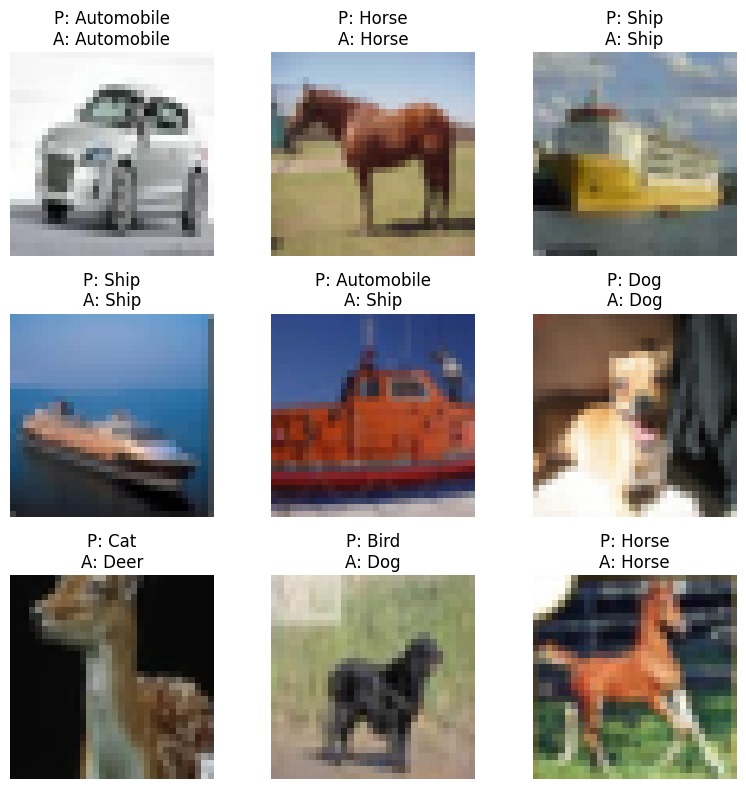

In [54]:
plt.figure(figsize = (8, 8))

indices = np.random.choice(
    len(X_test),
    9,
    replace=False
)

for i, index in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[index])
    plt.title(f"P: {classes[predictions[index]]}\nA: {classes[actual[index]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()